#### **Importing all the libraries**

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### **1. Loading the Image and adding the Guassian Blur**

In [42]:
img_color = cv2.imread("img.jpg")
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(img_gray, (15, 15), 0)


#### **PART A: Canny Edge Detection & Threshold Tuning**

In [45]:
# 1. Default Thresholds (50, 150)
edges_default = cv2.Canny(blurred, 50, 150)

# 2. Tuned Thresholds (e.g., 80, 220)
# Note: Adjust these if your specific lighting creates different shadow gradients
edges_tuned = cv2.Canny(blurred, 10, 50)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
edges_closed = cv2.morphologyEx(edges_tuned, cv2.MORPH_CLOSE, kernel)

#### **PART B: Contour Detection & Artifact Rejection**

--- [TASK 5 AUTO-COUNT LOG] ---
Total objects placed in frame: 3 (Known Ground Truth)
Raw contours detected (including noise): 52
Final Auto-Count (after area filter): 8
-------------------------------


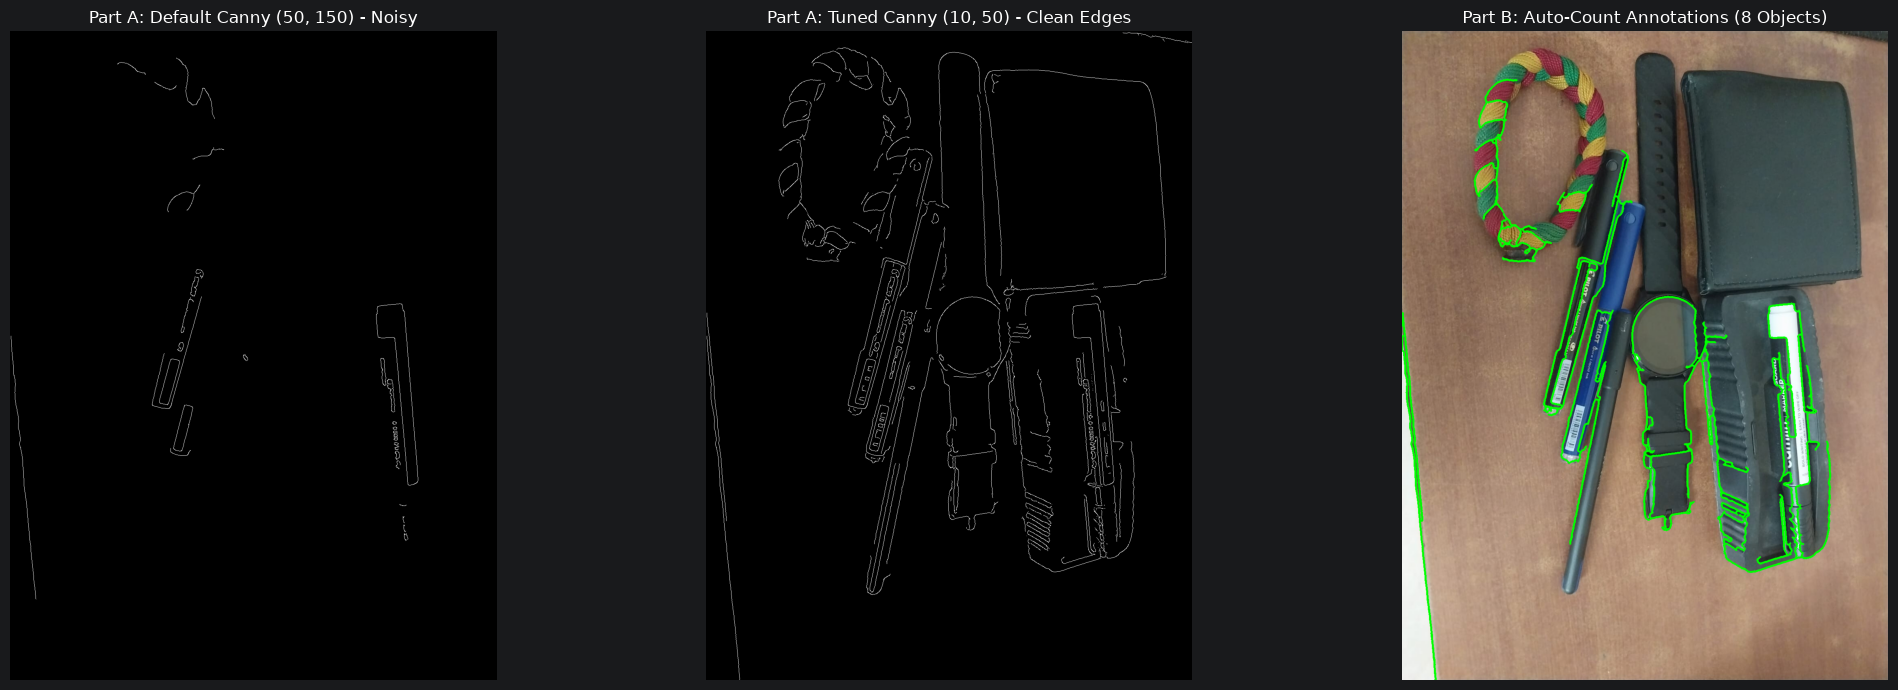

In [47]:
contours,hierarchy = cv2.findContours(edges_closed,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)


valid_contours = []
min_area_threshold = 800

for cnt in contours:
    if cv2.contourArea(cnt) > min_area_threshold:
        valid_contours.append(cnt)

# 4. Annotate the original color image
annotated_img = img_color.copy()
cv2.drawContours(annotated_img, valid_contours, -1, (0, 255, 0), 4)

# Console Output Log for Mentor Validation
print("--- [TASK 5 AUTO-COUNT LOG] ---")
print(f"Total objects placed in frame: 3 (Known Ground Truth)")
print(f"Raw contours detected (including noise): {len(contours)}")
print(f"Final Auto-Count (after area filter): {len(valid_contours)}")
print("-------------------------------")

# =====================================================================
# VISUALIZATION
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

axes[0].imshow(edges_default, cmap='gray')
axes[0].set_title('Part A: Default Canny (50, 150) - Noisy')
axes[0].axis('off')

axes[1].imshow(edges_tuned, cmap='gray')
axes[1].set_title('Part A: Tuned Canny (10, 50) - Clean Edges')
axes[1].axis('off')

# Convert BGR to RGB for correct color rendering in Matplotlib
axes[2].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Part B: Auto-Count Annotations ({len(valid_contours)} Objects)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

I had to change the canny edges for the edges_tuned for 5 times to achieve the proper Contouring and edge_tuned = cv2.Canny(blurred,10,50) was the final value which led to proper contouring